# gamry-parser: chronoamperometry

`gamry_parser.read()` parses a Gamry EXPLAIN (DTA) file and returns an experiment whose curves are polars DataFrames.
This notebook reads the two chronoamperometry fixtures in the repository: one written with a decimal point, one with
a decimal comma.

In Google Colab, first add a cell with `%pip install -q gamry-parser matplotlib`, then point `DATA_FILES` at your own
files.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

import gamry_parser as gp

DATA_FILES = [Path("../tests/data/chronoa_data.dta"), Path("../tests/data/chronoa_de_data.dta")]
OUTPUT_CSV = Path("chronoa_curves.csv")

In [2]:
experiments = {path.name: gp.read(path) for path in DATA_FILES}
for name, exp in experiments.items():
    print(f"{name}: {type(exp).__name__}, {exp.curve_count} curve(s), started {exp.start_time}")
    print(f"  sample period {exp.sample_time} s, {exp.sample_count} samples")

chronoa_data.dta: ChronoAmperometry, 1 curve(s), started 2019-03-10 12:00:00
  sample period 30.0 s, 10 samples
chronoa_de_data.dta: ChronoAmperometry, 1 curve(s), started 2019-03-10 12:00:00
  sample period 30.0 s, 10 samples


In [3]:
experiments["chronoa_data.dta"].curve()

T,Vf,Im
f64,f64,f64
0.0,-0.00054,-2.3420e-8
30.0,0.499669,1.4044e-8
60.0,0.499668,9.3278e-9
90.0001,0.499659,7.5206e-9
120.0,0.499654,6.3708e-9
150.0,0.499657,5.4468e-9
180.0,0.499661,4.8695e-9
210.0,0.499667,4.4386e-9
240.0,0.49966,4.0772e-9


`timestamps=True` replaces the elapsed-seconds `T` column with datetimes.

In [4]:
experiments["chronoa_data.dta"].curve(timestamps=True).head()

T,Vf,Im
datetime[μs],f64,f64
2019-03-10 12:00:00,-0.00054,-2.3420e-8
2019-03-10 12:00:30,0.499669,1.4044e-8
2019-03-10 12:01:00,0.499668,9.3278e-9
2019-03-10 12:01:30.000100,0.499659,7.5206e-9
2019-03-10 12:02:00,0.499654,6.3708e-9


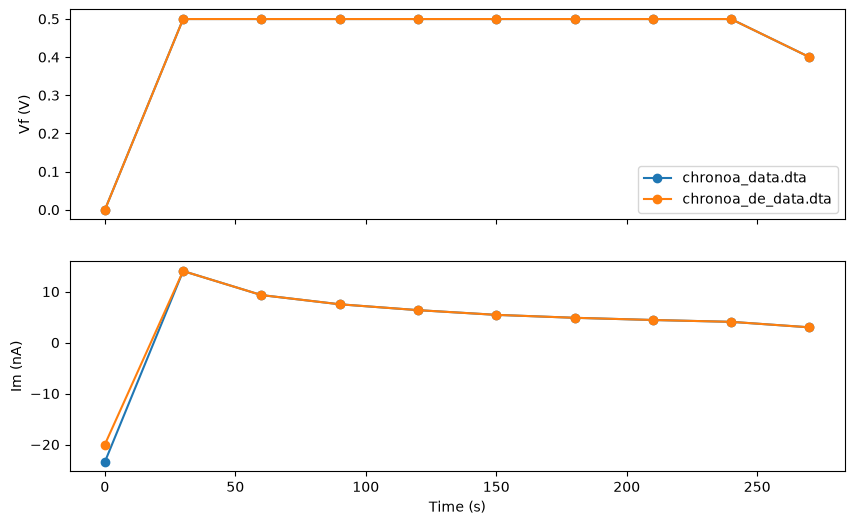

In [5]:
fig, (ax_v, ax_i) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
for name, exp in experiments.items():
    curve = exp.curve()
    ax_v.plot(curve["T"], curve["Vf"], marker="o", label=name)
    ax_i.plot(curve["T"], curve["Im"] * 1e9, marker="o", label=name)
ax_v.set_ylabel("Vf (V)")
ax_i.set_ylabel("Im (nA)")
ax_i.set_xlabel("Time (s)")
ax_v.legend()
plt.show()

Combine every curve from every file into one frame and save it as CSV.

In [6]:
all_curves = pl.concat(
    [
        curve.with_columns(file=pl.lit(name), curve=pl.lit(index))
        for name, exp in experiments.items()
        for index, curve in enumerate(exp.curves)
    ]
)
all_curves.write_csv(OUTPUT_CSV)
all_curves

Pt,T,Vf,Im,Vu,Sig,Ach,IERange,Over,file,curve
i64,f64,f64,f64,f64,f64,f64,i64,str,str,i32
0,0.0,-0.00054,-2.3420e-8,0.0,0.0,-0.000667,6,"""...........""","""chronoa_data.dta""",0
1,30.0,0.499669,1.4044e-8,0.0,0.5,-0.000664,6,"""...........""","""chronoa_data.dta""",0
2,60.0,0.499668,9.3278e-9,0.0,0.5,-0.000663,6,"""...........""","""chronoa_data.dta""",0
3,90.0001,0.499659,7.5206e-9,0.0,0.5,-0.000666,6,"""...........""","""chronoa_data.dta""",0
4,120.0,0.499654,6.3708e-9,0.0,0.5,-0.000665,6,"""...........""","""chronoa_data.dta""",0
…,…,…,…,…,…,…,…,…,…,…
5,150.0,0.499657,5.4468e-9,0.0,0.5,-0.000665,6,"""...........""","""chronoa_de_data.dta""",0
6,180.0,0.499661,4.8695e-9,0.0,0.5,-0.000666,6,"""...........""","""chronoa_de_data.dta""",0
7,210.0,0.499667,4.4386e-9,0.0,0.5,-0.000664,6,"""...........""","""chronoa_de_data.dta""",0
